# DS4200 Homework 10

Due: Friday Apr 10th @ 11:59 PM EST

### Submission Instructions
Submit this `ipynb` file included with the coding results to Gradescope (this can also be done via the assignment on Canvas).  To ensure that your submitted files represent your latest code, make sure to give a fresh `Kernel > Restart & Run All` just before uploading the files to gradescope.

### Tips for success
- Start early
- Make use of Piazza
- Make use of Office hour
- Remember to use cells and headings to make the notebook easy to read (if a grader cannot find the answer to a problem, you will receive no points for it)
- Under no circumstances may one student view or share their ungraded homework or quiz with another student [(see also)](http://www.northeastern.edu/osccr/academic-integrity), though you are welcome to **talk about** (not show each other) the problems.

### Part 1 Exploratory vs. Explanatory writing

Following is an automobile data downloaded from the UCI repository. Here is the link for the data in case you cannot run the script. You can download the csv and run it. 

https://archive.ics.uci.edu/dataset/10/automobile


In [6]:
#pip install ucimlrepo

In [7]:
from ucimlrepo import fetch_ucirepo 
  
automobile = fetch_ucirepo(id=10)   
X = automobile.data.features 
X.head()

,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,...,length,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses
0,13495.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
1,16500.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
2,16500.0,26,19,5000.0,154.0,9.0,3.47,2.68,mpfi,152,...,171.2,94.5,front,rwd,hatchback,2.0,std,gas,alfa-romero,NaN
3,13950.0,30,24,5500.0,102.0,10.0,3.40,3.19,mpfi,109,...,176.6,99.8,front,fwd,sedan,4.0,std,gas,audi,164.0
4,17450.0,22,18,5500.0,115.0,8.0,3.40,3.19,mpfi,136,...,176.6,99.4,front,4wd,sedan,4.0,std,gas,audi,164.0


In [8]:
X.columns


Index(['price', 'highway-mpg', 'city-mpg', 'peak-rpm', 'horsepower',
       'compression-ratio', 'stroke', 'bore', 'fuel-system', 'engine-size',
       'num-of-cylinders', 'engine-type', 'curb-weight', 'height', 'width',
       'length', 'wheel-base', 'engine-location', 'drive-wheels', 'body-style',
       'num-of-doors', 'aspiration', 'fuel-type', 'make', 'normalized-losses'],
      dtype='str')

#### Part 1.1 Boxplot (15 points)

Following is boxplot between price and body style of the car. Please write: 

- **Exploratory interpretation (one paragraph):**  
  Write one paragraph that *explores* the visualization. Describe the overall patterns, trends, clusters, variability, and any notable outliers you observe, without assuming a specific message or audience. Your goal is to investigate what the data appear to show.

- **Explanatory interpretation (one paragraph):**  
  Write one paragraph that *explains* the visualization. Choose a specific message or insight you want to communicate (for example, how horsepower relates to price), and describe the plot as if you were presenting it to an audience to support that message.

- **AI reflection (one paragraph):**
  Without providing any additional context, upload or describe the visualization to a GenAI tool and ask it to interpret the visualization. *Copy and paste* the AI-generated response here. Compare your own interpretation with the AI’s output. Is the AI’s interpretation more aligned with an exploratory or an explanatory approach? Explain your reasoning.

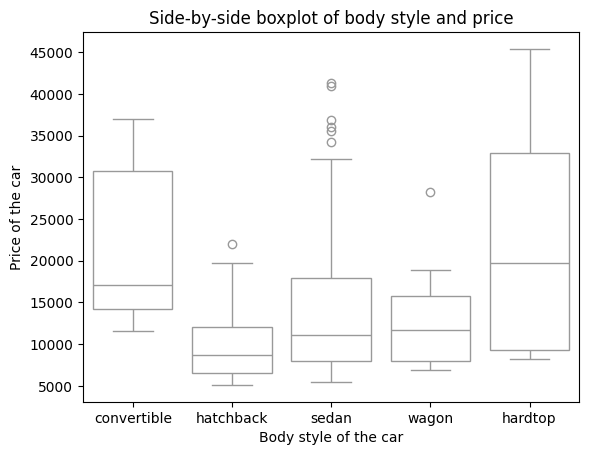

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x = X['body-style'], y = X['price'], color='white')

# Set plot labels
plt.xlabel('Body style of the car')
plt.ylabel('Price of the car')
plt.title('Side-by-side boxplot of body style and price')

# Show the plot
plt.show()

Exploratory: The figure is prices of different body styles of cars. Convertible body styles have a median price of about 17000, hatchbacks are about 8000, sedans are about 12000, wagons are about 13000, and hardtops are about 19000. Hatchbacks and wagons have one outlier each, while sedans have multiple outliers. Convertibles and hardtops have no outliers at all. Convertibles and hardtops also have quite large IQRs, while the rest don't. Hardtops have the highest maximum price, while hatchbacks have the smallest minimum price. All body styles are skewed-right.

Explanatory: The figure is prices of different body styles of cars. Generally, hatchbacks are the cheapest, followed by sedans, wagons, convertibles, and hardtops. However, sedans, convertibles, and hardtops have very large ranges. This means that these styles can be quite cheap, or very expensive. For these body styles, this may illustrate that there's levels of quality, where depending on the manufacturer, materials, and other factors, it can determine how good the quality is and the resulting price.

AI: This side-by-side boxplot compares car prices across different body styles (convertible, hatchback, sedan, wagon, hardtop). Here’s how to interpret it:

Overall patterns
* Hardtops and convertibles tend to be more expensive overall.
* Hatchbacks are generally the least expensive.
* Sedans and wagons fall in the middle price range.

By category
* Hardtop
    * Highest median price (around ~$20k).
    * Very wide spread → prices vary a lot.
    * Contains some of the most expensive cars (up to ~$45k).
* Convertible
    * Also relatively high median (~$17k).
    * Wide range, indicating both mid-range and premium models.
* Sedan
    * Moderate median (~$11k).
    * Large variability with many high-price outliers (some >$40k).
    * Suggests most sedans are affordable, but a few are luxury models.
* Wagon
    * Slightly higher median than sedan (~$12k).
    * Moderate spread, fewer extreme values.
* Hatchback
    * Lowest median (~$8–9k).
    * Narrower spread → prices are more consistent and generally lower.

Key insights
* Price variability is highest in hardtops, convertibles, and sedans.
* Outliers (especially in sedans) indicate luxury or high-performance versions.
* Budget buyers are most likely to find lower prices among hatchbacks.
* Premium segments are dominated by hardtops and convertibles.

----
The AI's interpretation is more on the exploratory side because it makes more inferences than it talks about things like variability and outliers. It rather talks about consistency of prices, how expensive they are, and talks about mid-range and premium level models.

#### Part 1.2 Scatterplot (20 points)

The figure below shows a scatter plot illustrating the relationship between a car’s price and its horsepower.

- **Exploratory interpretation (one paragraph):**  
  Write one paragraph that *explores* the visualization. Describe the overall patterns, trends, clusters, variability, and any notable outliers you observe, without assuming a specific message or audience. Your goal is to investigate what the data appear to show.

- **Explanatory interpretation (one paragraph):**  
  Write one paragraph that *explains* the visualization. Choose a specific message or insight you want to communicate (for example, how horsepower relates to price), and describe the plot as if you were presenting it to an audience to support that message.

- **Visualization modification (one paragraph):**  
  Propose at least **two different ways** to modify the scatter plot in order to strengthen or clarify different explanatory stories. You may **not add new data features**, but you may introduce additional **marks** (e.g., reference lines, annotations) or **visual channels** (e.g., color, size, opacity) to emphasize your chosen narratives. For each modification, briefly explain what story it helps highlight and why.

- **AI reflection (one paragraph):**
  Without providing any additional context, upload or describe the visualization to a GenAI tool and ask it to (1) interpret the visualization and (2) suggest at least one way to modify it to strengthen a specific argument. *Copy and paste* the AI-generated response here. Compare your own interpretation and proposed modification with the AI’s output. To what extent does the AI’s response align with your interpretation and suggested changes? 

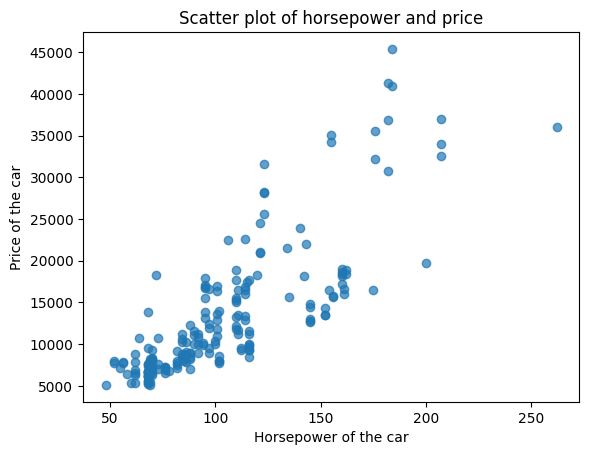

In [10]:
plt.scatter(y = X['price'], x = X['horsepower'], alpha=0.7)

# Set plot labels
plt.xlabel('Horsepower of the car')
plt.ylabel('Price of the car')
plt.title('Scatter plot of horsepower and price')

# Show the plot
plt.show()

Exploratory: The figure is horsepower of a car and the price of it. Most of the cars are clustered towards the lower left corner, from 150 and less horsepower and 25000 and under in price. There are some more cars that seem to be more like outliers, either having a somewhat higher horsepower for price or somewhat lower price for horsepower. There seems to be a decently positive correlation between both variables as it looks like a line with a positive slope can be drawn through the data.

Explanatory: The figure is of horsepower of cars and price of respective car. A lot of the cars seem to not have horsepower much over 150 and prices not much over 25000. However, there are some cars that have higher prices and horsepower. This indicates that most cars are cheaper, and therefore they have less horsepower. On the other hand, for cars that have more horsepower, they will have a more premium level pricing.

One change is to add a regression line through the data. This will help spot correlation as well as identify outliers. Another change is to slightly reduce the size of the points because a lot of them are overlapping each other. Making them a bit smaller will help easily spot all the different cars and their respective horsepowers, strengthening inferences drawn from the visualization.

AI: The scatter plot shows a clear positive relationship between horsepower and car price: as horsepower increases, prices tend to rise. Lower-horsepower cars (around 60–100 HP) cluster at lower prices, while higher-horsepower cars (150+ HP) are generally more expensive, though there is noticeable variability—especially in the mid-range—indicating other factors also influence price. A few high-horsepower points stand out as particularly expensive, suggesting possible premium or luxury models.

To strengthen the argument that horsepower strongly influences price, you could add a fitted regression line (trend line) to highlight the overall upward relationship. Including a correlation coefficient on the chart would further quantify the strength of this relationship.

------
For the most part, the interpretations are similar. Both mention a positive relationship between the variable, and that there's a cluster of lower horsepower cars with some higher ones, which have much bigger prices. However, the AI mentions that a couple points that stand out could be luxury models. The suggested changes are also similar, with both mentioning adding a regression line to highlight the relationship. One difference is that I mention reducing the size of the points while AI mentions adding a correlation coefficient to the chart.

#### Part 1.3 Organize your work (15 points)

Now you will write a **data analysis report** that uses **price** as the response variable to explain what factors affect fuel efficiency in cars. **You do NOT need to actually create the plots**—this is a planning and reasoning exercise focused on analysis and communication.

Choose **four features** from the dataset and propose **four corresponding visualizations** that you would use to support your analysis. For each visualization, provide a **one-sentence description** of what the plot would show, and then **list the four visualizations in the order** they would appear in your report.

Finally, write **one paragraph** explaining **why these four plots are important** for answering the research question and **why you chose this specific ordering**, discussing how the sequence helps build a clear and coherent narrative about the factors influencing MPG.


The four features I would choose are length, highway-mpg, engine size, and drive wheels. The first visualization would be a scatter plot, where the x-axis represents the length of the car and the y-axis is the price. The next would be a side-by-side boxplot, where each plot is by the drive wheel configuration and the response variable showing the distribution of prices for each configuration. Next would be a line plot of engine size and price, with engine size on the x and price on the y. Lastly, there would be another scatter plot, with highway-mpg on the x-axis and price on the y, and the color of each point encoding the drive wheel configuration.

The plots are important because each one illustrates the car characteristics related to price. The length-price scatter plot begins the report with a simple exposition of what effects larger vehicles have on their price. The drive-wheels boxplot adds on by comparing groups, showing how pricing distributions differ across drive wheel configurations. Next, the engine-size and price line plot introduces an often overlooked factor that directly ties in to cost. Finally, having the highway-mpg and price scatter plot (with color by drive wheels) closes off the report by connecting the price to fuel efficiency and its efficiency patterns with drive wheel configuration. This ordering ensures that the report starts more broad, and then slowly adds more and more context until ending with the main relationship being depicted.

### Part 2 In-class activities for the Interview (10 points)

In-class activities about the interview (The last slides for the peer-review and interview). Type your writing paragraph about the interview result as well as 3 visualization ideas based on the result.

The team I interviewed was doing a project about IMDb movie data. IMDb is a website that is about movies and TV shows. It has things such as the cast and crew, the average ratings, the genre, and many other such information about movies. Their plan is to analyze factors that have contributed to the success/failure of films and find trends about what genres may have been popular during certain years and decades. Furthermore, they are also looking to find specific films that are outliers among the general trends that they will find. The first visualization idea is a grouped bar chart of the popularity of movie genres for each decade. So the x-axis would have multiple decades and would be discrete, while the y-axis would have some sort of measure of popularity, whether that is number, or ratings, or whatnot. This would show trends of what kinds of films were popular throughout time. The next visualization idea is a scatterplot of movie ratings and box office numbers. The x-axis would be the rating out of 10 of the movie while the y-axis would be the box office returns in dollar amount. This would explore the relationship between movie quality and movie success, and whether movies are successful purely or mostly because of their reception. The last visualization idea is a density plot for each genre and the ratings movies in those genres get. This will show which genres tend to get higher or lower ratings, illustrating which types of movies the audiences tend to like.